In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# Read Data

dataset = pd.read_csv("metadata.csv")

print(dataset.head())
dataset.replace("UNK", np.nan, inplace = True)

  background_father background_mother  age  gender  smoke  drink  \
0               NaN               NaN    8     NaN    NaN    NaN   
1         POMERANIA         POMERANIA   55  FEMALE  False  False   
2               NaN               NaN   77     NaN    NaN    NaN   
3               NaN               NaN   75     NaN    NaN    NaN   
4         POMERANIA         POMERANIA   79    MALE  False   True   

  skin_cancer_history cancer_history pesticide  biopsed  ...   itch elevation  \
0                 NaN            NaN       NaN    False  ...  FALSE     FALSE   
1                True           True     False     True  ...   TRUE      TRUE   
2                 NaN            NaN       NaN    False  ...   TRUE     FALSE   
3                 NaN            NaN       NaN    False  ...   TRUE     FALSE   
4                True          False     False     True  ...   TRUE      TRUE   

  changed diameter_1 diameter_2 has_sewage_system has_piped_water  race  \
0   FALSE        NaN        N

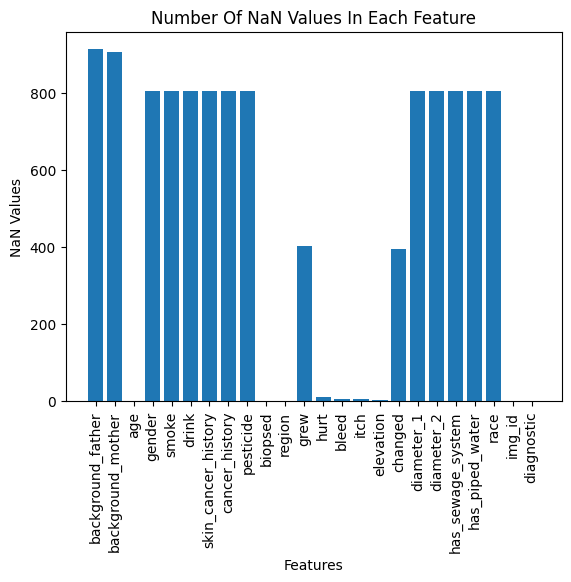

In [24]:
# NaN Values Visualization

columns = dataset.isnull().sum().keys()
values = dataset.isnull().sum().values

plt.bar(columns, values)
plt.title("Number Of NaN Values In Each Feature")
plt.xlabel("Features")
plt.ylabel("NaN Values")
plt.xticks(rotation = 90)
plt.show()

C:\Users\Moham\AppData\Local\Temp\ipykernel_16808\2526030934.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


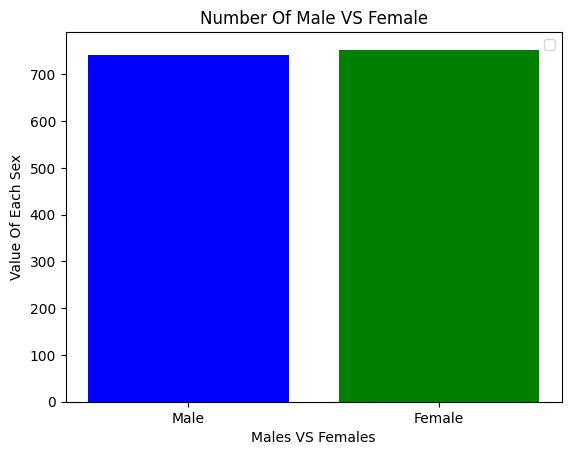

In [25]:
# Labeld Data

# MALE: 1, FEMALE: 0
dataset["gender"] = dataset["gender"].map({"MALE": 1, "FEMALE": 0})

sexCount = [(dataset["gender"] == 1).sum(), (dataset["gender"] == 0).sum()]
plt.bar(["Male", "Female"], sexCount, color = ["blue", "green"])
plt.title("Number Of Male VS Female")
plt.xlabel("Males VS Females")
plt.ylabel("Value Of Each Sex")
plt.legend()
plt.show()

# TRUE: 1, FALSE: 0
binaryColumns = ["smoke", "drink", "skin_cancer_history", "cancer_history", "pesticide", "biopsed", "grew", 
                 "hurt", "bleed", "itch", "elevation", "changed", "has_sewage_system", "has_piped_water"]

for column in binaryColumns:
  if(dataset[column].dtype == bool):
    dataset[column] = dataset[column].map({True: 1, False: 0})


for column in binaryColumns:
  if(dataset[column].dtype == object):
    dataset[column] = dataset[column].astype(str).str.upper().str.strip().map({"TRUE": 1, "FALSE": 0})

# Mode Metohd
mode_value = dataset["region"].mode()[0]
dataset["region"] = dataset["region"].fillna(mode_value)
dataset = pd.get_dummies(data = dataset, columns = ["region"], dtype = int, drop_first = True)

In [26]:
# KNNImputer

from sklearn.impute import KNNImputer

knnImputer = KNNImputer(missing_values = np.nan, n_neighbors = 5, weights = "uniform")
knnCols = dataset.columns[2:21]
dataset[knnCols] = knnImputer.fit_transform(dataset[knnCols])

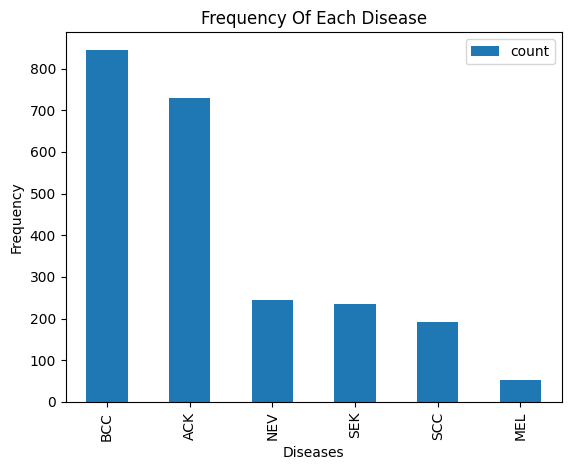

In [27]:
# Diseases Visualization

diseases_count = dataset["diagnostic"].value_counts()

diseases_count.plot(kind = "bar")
plt.title("Frequency Of Each Disease")
plt.xlabel("Diseases")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [28]:
# Normalization

from sklearn.preprocessing import StandardScaler

normColumns = ["age", "diameter_1", "diameter_2", "race"]
# sc_age = StandardScaler()
# dataset["age"] = sc_age.fit_transform(dataset[["age"]])
# sc_di1 = StandardScaler()
# dataset["diameter_1"] = sc_di1.fit_transform(dataset[["diameter_1"]])
# sc_di2 = StandardScaler()
# dataset["diameter_2"] = sc_di2.fit_transform(dataset[["diameter_2"]])

sc = StandardScaler()
dataset[normColumns] = sc.fit_transform(dataset[normColumns])

In [29]:
# Export Dataset, Standard Scalers

import pickle

with open("dataset.pkl", "wb") as f:
  pickle.dump(dataset, f)

with open("sc.pkl", "wb") as f:
  pickle.dump(sc, f)